In [2]:
import numpy as np,pandas as pd,seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv(r"C:\Users\SUBRATA\Desktop\India_JobMarket.csv")

In [85]:
df.sample(5)

,Job ID,Job Title,Department,City,State,Company,Experience,Salary (LPA),Skills,Education,Work Mode,Industry,Posted Month,Salary
331,JOB00332,Marketing Analyst,Marketing,Delhi,Delhi,TCS,1-3,12.5,Excel,MBA,On-site,E-commerce,Dec,1250000.0
137,JOB00138,HR Executive,HR,Chennai,Tamil Nadu,TCS,1-3,8.3,"Python, SQL",Any Graduate,Hybrid,Healthcare,Jun,830000.0
683,JOB00684,Marketing Analyst,Marketing,Gurugram,Haryana,Infosys,1-3,23.2,Excel,BTech,On-site,IT,Sep,2320000.0
103,JOB00104,Software Engineer,Software,Bengaluru,Karnataka,Flipkart,1-3,22.3,"Python, SQL",BTech,Remote,Healthcare,Jan,2230000.0
388,JOB00389,HR Executive,HR,Mumbai,Maharashtra,Accenture,5+,14.7,Excel,BTech,Hybrid,E-commerce,Nov,1470000.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Job ID        1000 non-null   str    
 1   Job Title     1000 non-null   str    
 2   Department    1000 non-null   str    
 3   City          1000 non-null   str    
 4   State         1000 non-null   str    
 5   Company       1000 non-null   str    
 6   Experience    1000 non-null   str    
 7   Salary (LPA)  1000 non-null   float64
 8   Skills        1000 non-null   str    
 9   Education     1000 non-null   str    
 10  Work Mode     1000 non-null   str    
 11  Industry      1000 non-null   str    
 12  Posted Month  1000 non-null   str    
dtypes: float64(1), str(12)
memory usage: 101.7 KB


In [16]:
#Which city offers the best salary-to-opportunity ratio?
result=df.groupby("City").agg(total_job=("Job ID","count"),Avg_Salary=("Salary (LPA)", "mean"))
result["Salary_to_Opportunity_Ratio"] = (result["Avg_Salary"] / result["total_job"])
result=result.sort_values(by="Salary_to_Opportunity_Ratio",ascending=False)
print(result)

           total_job  Avg_Salary  Salary_to_Opportunity_Ratio
City                                                         
Mumbai           109   12.877982                     0.118147
Hyderabad        119   13.675630                     0.114921
Kolkata          119   13.475630                     0.113241
Chennai          125   13.715200                     0.109722
Bengaluru        125   12.940800                     0.103526
Gurugram         140   14.057857                     0.100413
Pune             139   13.953237                     0.100383
Delhi            124   12.312903                     0.099298


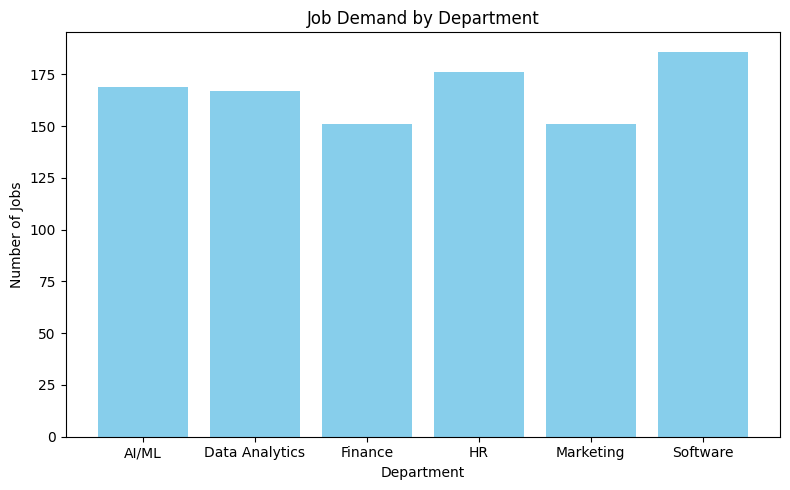

In [31]:
#Which department has the highest demand growth?
total_jobs=df.groupby("Department")["Job ID"].count()
plt.figure(figsize=(8,5))
plt.bar(total_jobs.index,total_jobs.values,color="skyblue",)
plt.title("Job Demand by Department")   
plt.xlabel("Department")                
plt.ylabel("Number of Jobs")           
plt.tight_layout()                      
plt.show()



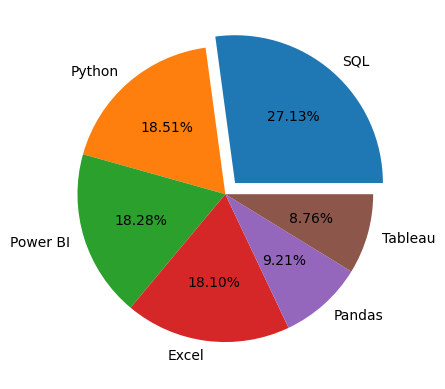

In [45]:
#What are the most frequently required skills?
skills_count= (
    df["Skills"]
    .str.split(",").explode().str.strip().value_counts())
plt.pie(skills_count,labels=skills_count.index,autopct="%1.2f%%",explode=[0.1,0,0,0,0,0])
plt.show()

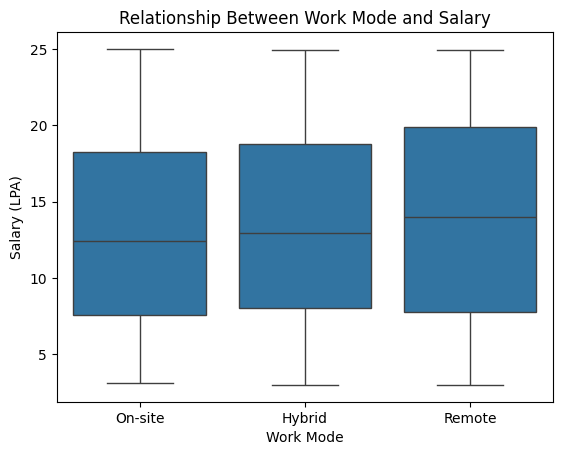

In [52]:
#Is there a relationship between work mode and salary?
sns.boxplot(data=df, x="Work Mode", y="Salary (LPA)")
plt.title("Relationship Between Work Mode and Salary")
plt.xlabel("Work Mode")
plt.ylabel("Salary (LPA)")
plt.show()

In [59]:
#Which industries hire the most Data Analytics professionals?
da_jobs = df[df["Department"] == "Data Analytics"]
industry_count = da_jobs["Industry"].value_counts()
print(industry_count)

Industry
IT            50
Healthcare    45
E-commerce    41
BFSI          31
Name: count, dtype: int64


In [75]:
#What percentage of jobs require SQL?
sql = df[df["Skills"].str.contains("SQL", na=False)]
sql_percentage = (len(sql) / len(df)) * 100
print("percentage of jobs require SQL : ",sql_percentage,"%")

percentage of jobs require SQL :  59.8 %


In [87]:
#What percentage of jobs require python?
python=df[df["Skills"].str.contains("Python",na=False)]
python_per=(len(python)/len(df))*100
print("percentage of jobs require SQL : ",python_per,"%")

percentage of jobs require SQL :  40.8 %


In [91]:
#Which skill combination appears most frequently?
result = df.groupby("Skills")["Job ID"].count().sort_values(ascending=False)
print(result.head())

Skills
Python, SQL                 205
Python, Pandas, Power BI    203
SQL, Excel, Power BI        200
Excel                       199
SQL, Tableau                193
Name: Job ID, dtype: int64
